In [1]:
import joblib 

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
dfs = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
# target = targets[targets["Experiment_ID"]==2].iloc[:, 2:]
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])
dfs

,Experiment_ID,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%],BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],BEND-DIE_VERTICAL_Movement_[mm],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm]
Time_[s],,,,,,,,,,,,,,,,,,
0.00,2,0.135068,0.817045,0.293651,0.436154,0.397692,0.107143,0.985937,0.757580,0.59375,0.999967,1.000000,0.456468,0.570124,0.000005,0.900879,0.000373,0.999849
0.05,2,0.135068,0.817045,0.285714,0.436154,0.397822,0.107143,0.985937,0.750271,0.59375,0.999967,1.000000,0.456468,0.570124,0.000004,0.900879,0.000373,0.999842
0.10,2,0.135068,0.817045,0.293651,0.436154,0.398065,0.107143,0.984375,0.698300,0.59375,0.999967,1.000000,0.456468,0.570124,0.000004,0.900879,0.000373,0.999540
0.15,2,0.136307,0.817045,0.293651,0.436154,0.397887,0.107143,0.985937,0.585460,0.62500,0.999967,1.000000,0.456468,0.570124,0.000005,0.900879,0.000373,0.998401
0.20,2,0.135068,0.817045,0.285714,0.436154,0.397741,0.107143,0.984375,0.476972,0.65625,0.999967,1.000000,0.456468,0.570124,0.000002,0.900879,0.000373,0.997003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86.30,314,0.074349,0.875032,0.285714,0.419720,0.414831,0.785714,0.926562,0.793701,0.43750,0.000007,0.997979,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849
86.35,314,0.074349,0.872084,0.293651,0.419720,0.415124,0.785714,0.928125,0.793552,0.43750,0.000007,0.998670,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849
86.40,314,0.074349,0.874473,0.285714,0.419720,0.415188,0.785714,0.926562,0.793404,0.43750,0.000007,0.999223,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849


In [3]:
# import numpy as np

# # Keep features with variance above a threshold
# variance_threshold = 0.09
# dfs = dfs.loc[:, dfs.var() > variance_threshold]
# dfs

In [4]:
groups_y = []
max_len_y = targets.groupby("Experiment_ID").size().max()
num_target_features = targets.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in targets.groupby("Experiment_ID"):
    values = group.drop(columns=["Experiment_ID"]).values  # (len_group, num_target_features)
    
    # Pad with NaN
    padded = np.full((max_len_y, num_target_features), np.nan)
    padded[:values.shape[0], :] = values
    groups_y.append(padded)

# Final y: (num_experiments, max_len, num_target_features)
y = np.array(groups_y, dtype=float)

# Replace NaN with 0
Y = np.nan_to_num(y, nan=0.0)



groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)


X = np.array(groups, dtype=float)
X = np.nan_to_num(X, nan=0.0)[:5,:,:]
Y = np.nan_to_num(y, nan=0.0)[:5,:,2:3]
print("Shape:", X.shape, Y.shape)  

Shape: (5, 1743, 17) (5, 47, 1)


In [5]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# ---------- Dataset ----------
class AngleDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
        self.num_angles = Y.shape[1]

    def __len__(self):
        return self.X.shape[0] * self.num_angles

    def __getitem__(self, idx):
        example_idx = idx // self.num_angles
        angle_idx = idx % self.num_angles
        x = self.X[example_idx]  # (seq_len, num_features)
        degree = torch.tensor([angle_idx / (self.num_angles - 1)], dtype=torch.float32)
        y = self.Y[example_idx, angle_idx]  # (3,)
        return x, degree, y, angle_idx  # Return angle_idx as well

# ---------- Model with Multihead Attention ----------
class AnglePredictorTarget(nn.Module):
    def __init__(self, input_size, output_size=3, hidden_size=128, num_angles=36, num_heads=4):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.num_angles = num_angles

        # LSTM for sequence processing
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)

        # Angle embeddings
        self.angle_embedding = nn.Embedding(num_angles, hidden_size)

        # Multihead Attention
        self.multihead_attn = nn.MultiheadAttention(embed_dim=hidden_size, num_heads=num_heads, batch_first=True)

        # Final prediction
        self.fc_out = nn.Linear(hidden_size, output_size)

    def forward(self, x, degree, angle_indices, y_target=None):
        # x: (batch, seq_len, input_size)
        # degree: (batch, 1)
        # angle_indices: (batch,)
        lstm_out, _ = self.lstm(x)  # (batch, seq_len, hidden_size)

        # Get angle embeddings
        angle_emb = self.angle_embedding(angle_indices)  # (batch, hidden_size)
        query = angle_emb.unsqueeze(1)  # (batch, 1, hidden_size)

        # Multihead Attention
        context, attn_weights = self.multihead_attn(query=query, key=lstm_out, value=lstm_out)  # (batch, 1, hidden_size), (batch, 1, seq_len)
        context = context.squeeze(1)  # (batch, hidden_size)

        # Combine with angle embedding
        combined = context + angle_emb

        # Final prediction
        out = self.fc_out(combined)  # (batch, output_size)

        return out, attn_weights.squeeze(1)  # attn_weights: (batch, seq_len)

# ---------- Example Data ----------
# Replace this with your actual data
# num_samples = 100
# seq_len = 10
# num_features = 5
# num_angles = 36
# output_size = 3

# X = np.random.randn(num_samples, seq_len, num_features).astype(np.float32)
# Y = np.random.randn(num_samples, num_angles, output_size).astype(np.float32)

# ---------- Training Setup ----------
dataset = AngleDataset(X, Y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

model = AnglePredictorTarget(
    input_size=X.shape[2],
    output_size=Y.shape[2],
    num_angles=Y.shape[1],
    num_heads=4
)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# ---------- Training Loop ----------
epochs = 50  # Reduced for testing
for epoch in range(epochs):
    total_loss = 0
    num_samples_processed = 0
    loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for x_batch, degree_batch, y_batch, angle_indices in loop:
        optimizer.zero_grad()

        # Ensure angle_indices is tensor
        angle_indices = angle_indices.long()

        y_pred, attn_weights = model(x_batch, degree_batch, angle_indices, y_target=y_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        batch_size = x_batch.size(0)
        total_loss += loss.item() * batch_size
        num_samples_processed += batch_size
        avg_loss_so_far = total_loss / num_samples_processed
        loop.set_postfix(avg_loss=avg_loss_so_far)

    print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {total_loss / len(dataset):.6f}")


KeyboardInterrupt: 

In [70]:
# Save model 
joblib.dump(model, "lstm.pkl")

['lstm.pkl']

In [6]:
model = joblib.load("lstm.pkl")

Comparing predictions for example 0:
--------------------------------------------------
Angle  0: Pred=[0.32766616], True=[0.31746134], MSE=0.000104
Angle 10: Pred=[0.29293147], True=[0.34018287], MSE=0.002233
Angle 20: Pred=[0.22945979], True=[0.18674312], MSE=0.001825
Angle 30: Pred=[0.19598746], True=[0.12109847], MSE=0.005608
Angle 35: Pred=[0.13380542], True=[0.12850855], MSE=0.000028


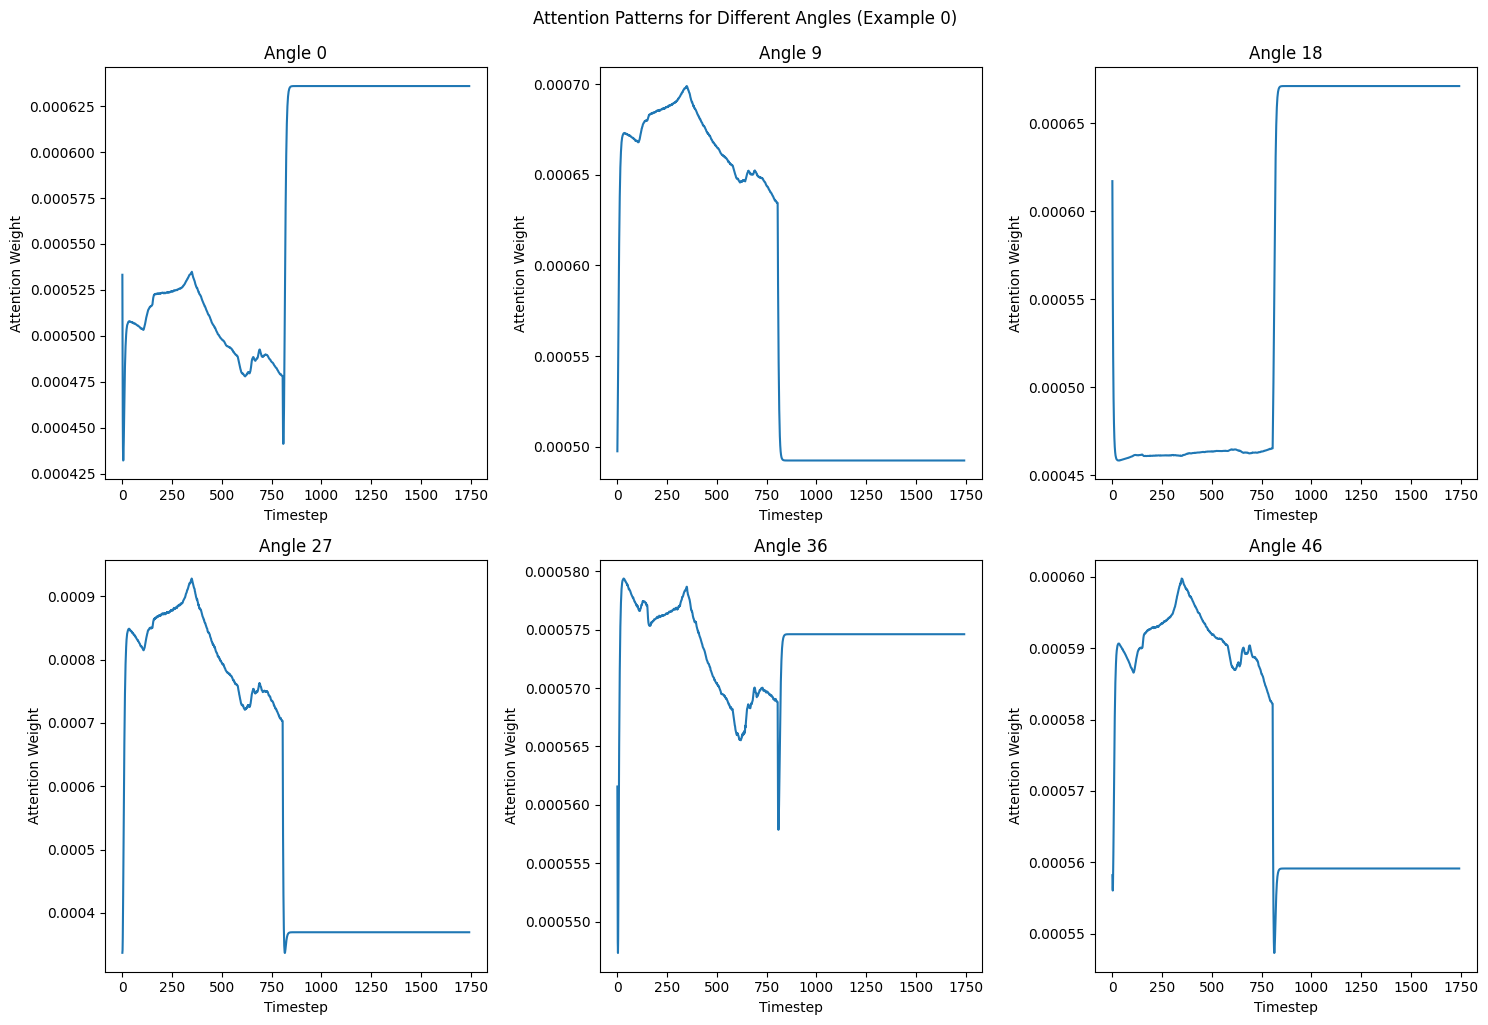

In [7]:

# ---------- Visualize Attention for Different Angles ----------
def plot_angle_attentions(model, X, Y, example_idx=0, num_angles_to_plot=6):
    model.eval()
    
    angles_to_plot = np.linspace(0, Y.shape[1]-1, num_angles_to_plot, dtype=int)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, angle_idx in enumerate(angles_to_plot):
        if i >= len(axes):
            break

        x_example = torch.tensor(X[example_idx:example_idx+1], dtype=torch.float32)
        degree = torch.tensor([[angle_idx / (Y.shape[1]-1)]], dtype=torch.float32)
        y_target = torch.tensor(Y[example_idx, angle_idx:angle_idx+1], dtype=torch.float32)
        angle_index_tensor = torch.tensor([angle_idx], dtype=torch.long)

        with torch.no_grad():
            y_pred, attn_weights = model(x_example, degree, angle_index_tensor, y_target=y_target)
            attn_weights = attn_weights.squeeze().numpy()

        axes[i].plot(attn_weights)
        axes[i].set_title(f"Angle {angle_idx}")
        axes[i].set_xlabel("Timestep")
        axes[i].set_ylabel("Attention Weight")
    
    plt.tight_layout()
    plt.suptitle(f"Attention Patterns for Different Angles (Example {example_idx})", y=1.02)
    plt.show()

# ---------- Compare predictions ----------
def compare_predictions(model, X, Y, example_idx=0):
    model.eval()
    print(f"Comparing predictions for example {example_idx}:")
    print("-" * 50)
    
    test_angles = [0, 10, 20, 30, 35]
    
    for angle_idx in test_angles:
        x_example = torch.tensor(X[example_idx:example_idx+1], dtype=torch.float32)
        degree = torch.tensor([[angle_idx / (Y.shape[1]-1)]], dtype=torch.float32)
        y_target = torch.tensor(Y[example_idx, angle_idx:angle_idx+1], dtype=torch.float32)
        angle_index_tensor = torch.tensor([angle_idx], dtype=torch.long)

        with torch.no_grad():
            y_pred, attn_weights = model(x_example, degree, angle_index_tensor, y_target=y_target)
            pred = y_pred.numpy().flatten()
            true = Y[example_idx, angle_idx]
            mse = np.mean((pred - true) ** 2)

        print(f"Angle {angle_idx:2d}: Pred={pred}, True={true}, MSE={mse:.6f}")

# ---------- Example usage ----------
compare_predictions(model, X, Y, example_idx=0)
plot_angle_attentions(model, X, Y, example_idx=0, num_angles_to_plot=6)